# Programowanie matematyczne

Programowanie matematyczne to dział informatyki zajmujący się znajdowaniem optymalnego rozwiązania konkretnego problemu  spośród wszystkich możliwych rozwiązań spełniających określone warunki. Czyli ujmując definicję w dużym skrócie: opisujemy problem za pomocą wzorów matematycznych (model matematyczny), a następnie używamy gotowych algorytmów (w postaci solverów), celem znalezienia optymalnych wartości parametrów.

Warto podkreślić, że programowanie matematyczne nie oznacza bezpośrednio pisania kodu. Pojęcie w swojej istocie odnosi się do planowania i optymalnego doboru zasobów, co oznacza plan działania, czyli program. Co istotne, w epoce wczesnej informatyki (np. algorytm Simplex, 1947) termin programowanie nie był jeszcze kojarzony w sposób oczywisty z pisaniem kodu, stąd pojęcie programowanie matematyczne otrzymało współcześnie wieloznaczny termin.

W programowaniu matematycznym wyróżnia się główne klasy problemów

1. Programowanie liniowe (ang. linear programming, LP)
   1. Wszystkie zależności, zarówno funkcja celu, jak i ograniczenia, są funkcjami liniowymi, a parametry mogą przyjmować dowolne wartości rzeczywiste.
   2. Przykładowo: optymalizacja składu mieszanki paliwowej lub planu produkcji minimalizującego koszty przy podanych limitach składników.
2. Programowaie całkowitoliczbowe (ang. integer programming, IP)
   1. Rodzina zawarta w metodach programowania liniowego. Parametry modelu muszą być liczbami całkowitymi, lub binarnymi.
   2. Przykładowo: model wspomagający decyzję lekarską.
3. Mieszane programowanie liniowo-całkowitoliczbowe (ang. mixed-integer linear programming, MILP)
   1. Połączenie LP oraz IP, gdzie część parametrów w modelu jest całkowitoliczbowa, a część rzeczywista.
   2. Przykładowo: harmonogramowanie pracy rafinerii lub planowanie tras dostaw z uwzględnieniem czasu pracy kierowców i liczby ciężarówek.
4. Programowanie nieliniowe (ang. nonlinear programming, NLP)
   1. Przynajmniej jedna funkcja (w celu lub ograniczeniach) jest nieliniowa, czyli występują tam zależności wielomianowe, funkcje trygonometryczne, itd. Jest to najczęściej stosowany paradygmat programowania matematycznego z uwagi na mnogość zależności nieliniowych występujących w rzeczywistości.
   2. Przykładowo: optymalizacja procesów chemicznych, gdzie reakcje zależą typowo od temperatury i ciśnienia w sposób nieliniowy.

W optymalizacji, oprócz programowania matematycznego, wyróżnia się także metody heurystyczne oraz numeryczne, gdzie każda z nich jest przeznaczona dla konkretnej grupy problemów optymalizacyjnych. W przypadku programowania matematycznego wymogiem jest posiadanie jawnej struktury funkcji matematycznej, reprezentowanej jako model. Algorytmy dokonujące optymalizacji w wariancie programowania matematycznego traktują model jako białą skrzynkę, czyli wykorzystują właściwości analityczne wzoru do wyznaczenia optymalnego rozwiązania.

Modele matematyczne optymalizowane w ten sposób muszą spełniać następujące własności:
- jawność funkcji celu i ograniczeń, co zapewnia algorytmom optymalizacyjnym możliwość stosowania rachunku różniczkowego,
- liniowość i wypukłość, gdzie funkcje liniowe tworzą przestrzeń rozwiązań w postaci wielościanu, gdzie ekstrema zawsze leżą na wierzchołkach, a funkcje wypukłe gwarantują równoważnośc minimów lokalnych i globalnych,
- dyskretnośc i nieciągłość dla zmiennych całkowitoliczbowych lub binarnych, gdzie funkcja celu przyjmuje postać dyskretną (kombinatoryczną). Programowanie matematyczne radzi sobie z nimi poprzez matematyczne dzielenie i odcinanie przestrzeni rozwiązań.

Kiedy stosować programowanie matematyczne? Zawsze, gdy problem da się sformułować jako model matematyczny, w szczególności liniowy. Współczesne metody optymalizacyjne zapewniają w takich warunkach **gwarancję optymalności**.

Są przypadki, gdy programowanie matematyczne nie zapewnia gwarancji optymalności. W sytuacji gdy wzór funkcji celu nie jest znany, lub jest zbyt "dziki" / silnie nieliniowy / skokowy, stosuje się zazwyczaj metody heurystyczne. Gdy problem da się sprowadzić do modelu, gdzie występuje ciągła przestrzeń i gładka funkcję o ogromnej liczbie parametrów, dobrym rozwiązaniem mogą być metody gradientowe. Ale o tym w kolejnych wykładach...

## Programowanie matematyczne we współczesnym zestawie narzędzi

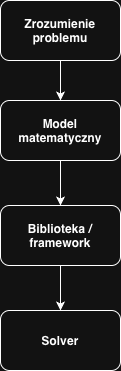

| Biblioteka / framework | LP | NLP | Próg wejścia | Łatwość współpracy z solverami |
| :--- | :---: | :---: | :---: | :---: |
| [Pyomo](https://pypi.org/project/pyomo/) | X | X | Niski | Wysoka |
| [Ortools](https://pypi.org/project/ortools/) | X | | Bardzo niski | Niska |
| [PuLP](https://pypi.org/project/PuLP/) | X | | Niski | Wysoka |
| [SCIP](https://pypi.org/project/PySCIPOpt/) | X | X | Bardzo niski | Niska |
| [SciPy](https://pypi.org/project/scipy/) | X | X | Umiarkowany | Umiarkowana |

| Solver | LP | NLP | Licencja |
| :--- | :---: | :---: | :---: |
| [Gurobi](https://www.gurobi.com) | X | | komercyjna |
| [Cplex](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) | X | | komercyjna |
| [CBC](https://github.com/coin-or/cbc) | X | | otwarta |
| [GLPK](https://www.gnu.org/software/glpk/glpk.html) | X | | otwarta |
| [IPOPT](https://github.com/coin-or/ipopt) | | X | otwarta |
| [SCIP](https://github.com/scipopt/scip) | X | X | otwarta |
| [Baron](https://minlp.com/baron-solver) | | X | komercyjna |

### Programowanie liniowe

#### Problem 1: optymalizacja prostej funkcji liniowej

funkcja celu: $max (x+y)$

ograniczenia:
- $-x + 2y \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [32]:
def draw_model(
        constraints: list,
        target_fn: callable,
        optimal_parameters: tuple | None = None,
        ) -> None:
    # definicja przestrzeni zmiennych (dziedzina)
    x_vals = np.linspace(0, 10, 500)
    y_vals = np.linspace(0, 10, 500)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = target_fn(X, Y)

    # obszar dopuszczalny, czyli część wspólna wszystkich ograniczeń
    feasible_region = np.logical_and.reduce([c(X, Y) for c in constraints])

    # wizualizacja
    plt.figure(figsize=(9, 7))
    contour = plt.contour(X, Y, Z, levels=20, cmap="viridis", alpha=0.6)
    plt.clabel(contour, inline=True, fontsize=9, fmt="z=%.1f")

    if optimal_parameters:
        plt.plot(*optimal_parameters, "ro", markersize=8, label=f"Optimum globalne {optimal_parameters}")
    
    plt.imshow(
        feasible_region,
        extent=(0, 10, 0, 10),
        origin="lower",
        cmap="Greens",
        alpha=0.4,
        aspect="auto",
    )

    colors = ["red", "blue", "green", "purple", "orange"]
    for c, color in zip(constraints, colors):
        plt.contour(
            X, Y, c(X, Y), levels=[0], colors=color, linestyles="dashed"
        )

    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        "Wizualizacja modelu matematycznego",
        fontsize=12,
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.colorbar(contour, label="Wartość funkcji celu (Z)")

    plt.show()

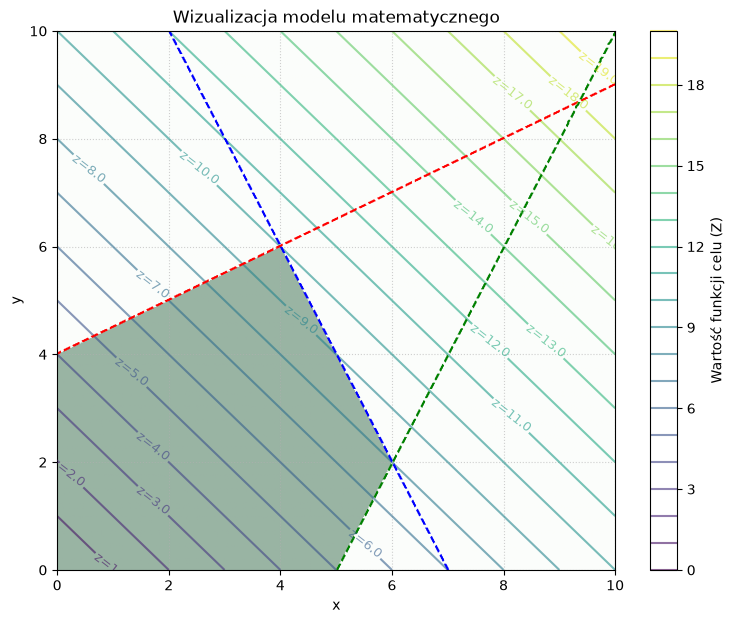

In [33]:
constraints = [
    lambda x, y: -x + 2 * y <= 8,
    lambda x, y: 2 * x + y <= 14,
    lambda x, y: 2 * x - y <= 10,
    lambda x, y: (x >= 0) & (x <= 10),
    lambda x, y: (y >= 0) & (y <= 10),
]
target = lambda x, y: x + y

draw_model(
    constraints=constraints,
    target_fn=target,
)

In [26]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

Pierwszym krokiem będzie utworzenie obiektu modelu matematycznego

In [27]:
model = pyo.ConcreteModel()

A następnie parametrów, które będa podlegały optymalizacji, czyli poszukiwaniu wartości w taki sposób, który zapewni maksymalną wartość funkcji kosztu. Tutaj ustawiamy zakres poszukiwań od 0 do 10 -- zgodny z ograniczeniami.

In [28]:
model.x = pyo.Var(bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

Oraz ustawiamy ograniczenia.

In [29]:
x = model.x
y = model.y

In [30]:
model.c1 = pyo.Constraint(expr= -x+2*y<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

I funkcję celu wraz z kierunkiem poszukiwań jej wartości. Tutaj maksymalizujemy, czyli poszukujemy **maksymalnej** wartości tej funkcji.

In [31]:
model.obj = pyo.Objective(expr= x+y, sense=pyo.maximize)

Dobrą praktyką jest okresowe podglądanie zawartości modelu. Będzie to miało szczególną wartość w przypadku bardziej złożonych problemów.

In [36]:
model.pprint()

2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   4.0 :    10 : False : False :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   6.0 :    10 : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : x + y

3 Constraint Declarations
    c1 : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : - x + 2*y :   8.0 :   True
    c2 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x + y :  14.0 :   True
    c3 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x - y :  10.0 :   True

6 Declarations: x y c1 c2 c3 obj


Poszukiwanie rozwiązań, czyli uruchomienie solvera.

In [34]:
opt = SolverFactory("glpk")

In [35]:
opt.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 10.0, 'Upper bound': 10.0, 'Number of objectives': 1, 'Number of constraints': 3, 'Number of variables': 2, 'Number of nonzeros': 6, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': 0, 'Number of created subproblems': 0}}, 'Error rc': 0, 'Time': 0.01014566421508789}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

Pobranie wyników

In [37]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [39]:
x_val, y_val

(4.0, 6.0)

#### Problem 2: Parametry tablicowe

Celem jest znalezienie takiej konfiguracji produkcji prądu w pięciu generatorach, aby zapewnić najtańszy prąd na żądanie do trzech punktów poboru. ABy nie było zbyt łatwo, załóżmy że punkt poboru 0 jest połączony tylko z generatorami 0 i 3.

| ID | Koszt 1 kW | Maksymalne obciążenie |
|----|------|----------------------|
| 0  | 0,10 | 20 kW                |
| 1  | 0,05 | 10 kW                |
| 2  | 0,30 | 40 kW                |
| 3  | 0,40 | 40 kW                |
| 4  | 0,01 | 5 kW                 |

| ID | Zapotrzebowanie|
|----|-------------|
| 0  | 50 kW       |
| 1  | 20 kW       |
| 2  | 30 kW       |

Założenia:
- C - koszt [zmienna]
- P [parametr] - aktualna produkcja prądu (kW)

Cel:
- $min \sum_{i_g = 0}^4 C_g(i_g)P_g(i_g)$

Ograniczenia:
- $\sum_{i_g = 0}^4 P_g(i_g) = \sum_{i_d = 0}^2 P_d(i_d)$ - suma aktualnie generowanego prądu musi odpowiadać sumie zapotrzebowań
- $P_d(0) \leq P_g(0) + P_g(3)$ - punkt poboru 0 jest połączony tylko z generatorami 0 i 3
- $P_g(i_g) \geq 0 \forall i_g$ - produkcja musi pochodzić ze wszystkich generatorów
- $P_g(i_g) \leq P_g(i_g)^{lim} \forall i_g$ - produkcja prądu nie moze przekroczyć maksymalnych mozliwości

In [40]:
import pandas as pd

In [41]:
energy_gen = pd.DataFrame.from_records([
    [0.10, 20],
    [0.05, 10],
    [0.30, 40],
    [0.40, 50],
    [0.01, 5 ],
], columns=["Cost", "Maximum power generation"])

In [42]:
energy_demand = pd.DataFrame.from_records([
    [50],
    [20],
    [30],
], columns=["Load demand"])

In [44]:
generator_amount = len(energy_gen)

In [53]:
model = pyo.ConcreteModel()

Parametr `pg` otrzyma tyle wartości, ile mamy dostępnych generatorów.

In [54]:
model.pg = pyo.Var(range(generator_amount), bounds=(0, None))
pg = model.pg

Ograniczenia

In [55]:
pg_sum = sum([pg[g] for g in range(generator_number)])
model.balance = pyo.Constraint(expr=(pg_sum == energy_demand["Load demand"].sum()))
model.cond = pyo.Constraint(expr=(pg[0] + pg[3] >= energy_demand["Load demand"][0]))

In [56]:
model.limits = pyo.ConstraintList()

for g in range(generator_amount):
    model.limits.add(expr=(pg[g] <= energy_gen["Maximum power generation"][g]))

In [57]:
model.minimums = pyo.ConstraintList()

for g in range(generator_amount):
    model.minimums.add(expr=(pg[g] >= 0))

Funkcja celu

In [58]:
model.obj = pyo.Objective(expr=(
    sum(pg[g] * energy_gen["Cost"][g] for g in range(generator_amount))
))

I... rozwiązanie

In [59]:
opt = SolverFactory("glpk")

In [60]:
results = opt.solve(model)

In [61]:
energy_gen["Expected generation"] = [pyo.value(pg[g]) for g in range(generator_number)]

In [62]:
energy_gen

,Cost,Maximum power generation,Expected generation
0,0.10,20,20.0
1,0.05,10,10.0
2,0.30,40,35.0
3,0.40,50,30.0
4,0.01,5,5.0


#### Problem 3. Optymalizacja grafowa

Problem numer 3 "trasowanie" z wykładu 0.

In [74]:
model = pyo.ConcreteModel()

In [75]:
model.all_points = ["A", "v1", "v2", "v3", "B"]
model.intermediate_points = ["v1", "v2", "v3"]

In [76]:
model.all_routes = [
    ["A", "v1"],
    ["A", "v2"],
    ["v1", "v2"],
    ["v2", "v1"],
    ["v1", "B"],
    ["v2", "v3"],
    ["v3", "B"],
]

In [77]:
model.routes_from = {key: [] for key in model.all_points}
model.routes_to = {key: [] for key in model.all_points}

In [78]:
for route in model.all_routes:
    model.routes_from[route[0]].append(route[1])
    model.routes_to[route[1]].append(route[0])

In [79]:
model.distances = {}
model.distances["A", "v1"] = 2
model.distances["A", "v2"] = 7
model.distances["v1", "v2"] = 10
model.distances["v2", "v1"] = 10
model.distances["v1", "B"] = 30
model.distances["v2", "v3"] = 8
model.distances["v3", "B"] = 5

Parametry modelu stanowią połączenia między węzłami (jest / brak)

In [80]:
model.x = pyo.Var(model.all_routes, within=pyo.Binary)

Funkcja celu: 

In [81]:
model.obj = pyo.Objective(expr= sum(
    [model.x[route[0], route[1]] * model.distances[route[0], route[1]] for route in model.all_routes]
), sense=pyo.minimize)

Ograniczenia modelu

In [82]:
model.c1 = pyo.Constraint(expr = sum([model.x["A", j] for j in model.routes_from["A"]]) == 1)
model.c2 = pyo.Constraint(expr = sum([model.x[i,"B"] for i in model.routes_to["B"]]) == 1)
model.c3 = pyo.ConstraintList()
for i in model.intermediate_points:
    model.c3.add(sum([model.x[i,j] for j in model.routes_from[i]]) == sum([model.x[j,i] for j in model.routes_to[i]]))

Rozwiązanie

In [83]:
opt = SolverFactory("glpk")
model.results = opt.solve(model)

Ostateczne rozwiązanie stanowią krawędzie, które otrzymały prawdziwe wartości logiczne.

In [84]:
for route in model.all_routes:
    if pyo.value(model.x[route[0], route[1]]) == 1:
        print('Route activated: %s-%s' % (route[0], route[1]))

Route activated: A-v2
Route activated: v2-v3
Route activated: v3-B


### (Mieszane) programowanie całkowitoliczbowe

Jak wiadomo, programowanie całkowitoliczbowe polega na przyjęciu dodatkowych założeń, gdzie wybrane parametry (wariant mieszany) lub wszystkie, przyjmują wartości całkowite. W bibliotece `pyomo` rozwiązuje się to za pomocą parametru `within=pyo.Integers` przekazywanego do inicjalizatora klasy `Var`.

Wykorzystamy problem 1 przedstawiony w programowaniu liniowym, gdzie pojawi się dodakowe założenie, że parametr `x` musi być całkowity.

In [85]:
model = pyo.ConcreteModel()

In [86]:
model.x = pyo.Var(within=pyo.Integers, bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [87]:
x = model.x
y = model.y

In [88]:
model.c1 = pyo.Constraint(expr= -x+2*y<=7)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [89]:
model.obj = pyo.Objective(expr= x+y, sense=pyo.maximize)

In [90]:
opt = SolverFactory("glpk")

In [91]:
opt.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 9.5, 'Upper bound': 9.5, 'Number of objectives': 1, 'Number of constraints': 3, 'Number of variables': 2, 'Number of nonzeros': 6, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': '3', 'Number of created subproblems': '3'}}, 'Error rc': 0, 'Time': 0.01608896255493164}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [92]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [93]:
x_val, y_val

(4.0, 5.5)

## Programowanie nieliniowe

W przypadku programowania nieliniowego warto zwrócić uwagę na solvery rozwiązujące tę rodzinę problemów. Solver `glpk` dostępny był jedynie dla modeli liniowych. W przypadku problemów nieliniowych, wykorzystamy solver `ipopt`.

Problemem do rozwiązania będzie następujący model nieliniowy.

funkcja celu: $max (x+xy)$

ograniczenia:
- $-x + 2yx \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

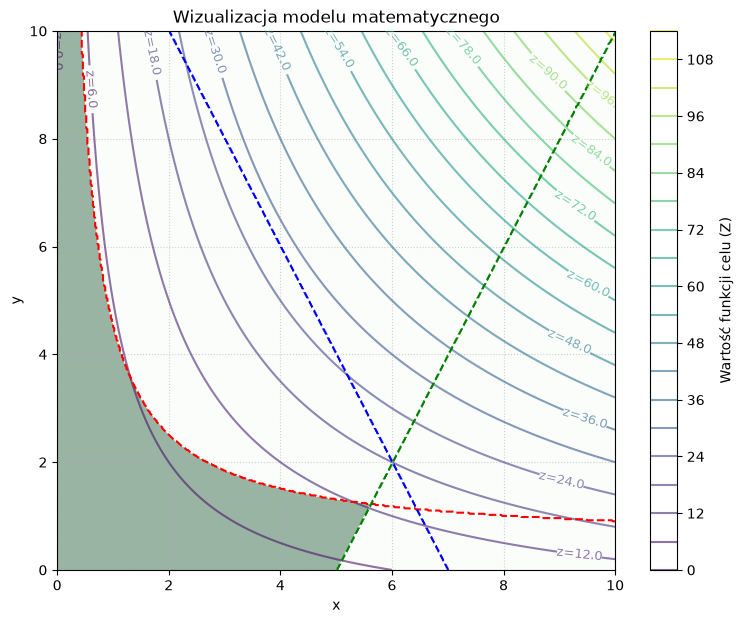

In [94]:
constraints = [
    lambda x, y: -x + 2 * x * y <= 8,
    lambda x, y: 2 * x + y <= 14,
    lambda x, y: 2 * x - y <= 10,
    lambda x, y: (x >= 0) & (x <= 10),
    lambda x, y: (y >= 0) & (y <= 10),
]
target = lambda x, y: x + x * y

draw_model(
    constraints=constraints,
    target_fn=target,
)

In [95]:
model = pyo.ConcreteModel()

In [96]:
model.x = pyo.Var(bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [97]:
x = model.x
y = model.y

In [98]:
model.c1 = pyo.Constraint(expr= -x+2*y*x<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [99]:
model.obj = pyo.Objective(expr= x+x*y, sense=pyo.maximize)

Warto zauważyć, że ścieżkę do pliku wykonywalnego solvera można przekazać bezpośrednio, za pomocą parametru `executable` w inicjalizatorze klasy `SolverFactory`.

In [100]:
opt = SolverFactory("ipopt", executable="/opt/homebrew/bin/ipopt")

In [101]:
opt.solve(model)

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 3, 'Number of variables': 2, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.14.20\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.1880021095275879}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [102]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [103]:
x_val, y_val

(5.6067151589768685, 1.2134302215032389)

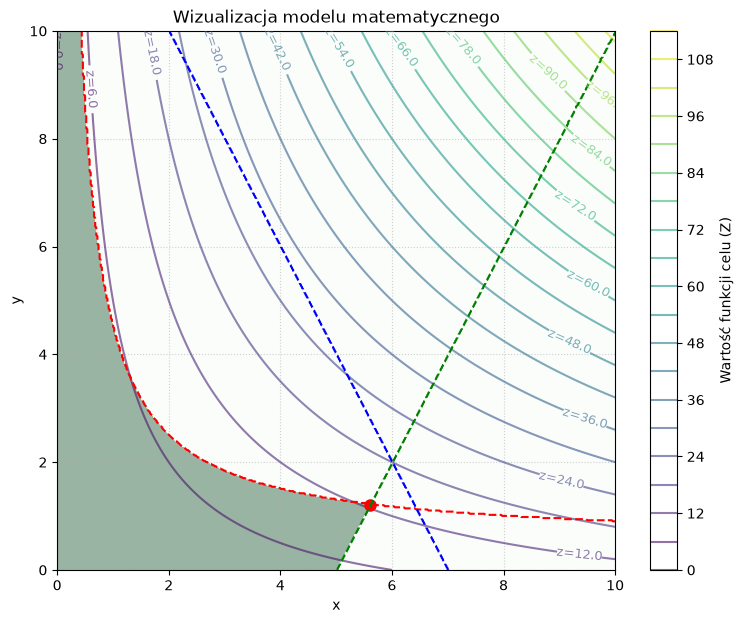

In [104]:
draw_model(
    constraints=constraints,
    target_fn=target,
    optimal_parameters=(x_val, y_val),
)

## Mieszane całkowitoliczbowe programowanie nieliniowe

Koncepcja mieszanego całkowitoliczbowego programowania nieliniowego powinna być już oczywista. Mamy do czynienia z nieliniowym modelem matematycznym, gdzie funkcja celu i/lub ograniczenia są nieliniowe. Co więcej, wybrane parametry będą przyjmowały jedynie wartości całkowite. Z punktu widzenia wyboru solvera, problematyka zdecydowanie zawęża dostępne rozwiązania. Biblioteka `pyomo` dostarcza jednak ciekawa funkcjonalność, która pozwoli połączyć ze sobą dwa solvery przeznaczone do rozwiązywania problemów atomowych, czyli NLP oraz MILP. Można dokonać tego za pomocą parametrów `mip_solver` oraz `nlp_solver` w metodzie `solve`.

Wykorzystamy problem optymalizacyjny z poprzedniego przykładu.

funkcja celu: $max (x+xy)$

ograniczenia:
- $-x + 2yx \leq 8$
- $2x + y \leq 14$
- $2x - y \leq 10$
- $0 \leq x \leq 10$
- $0 \leq y \leq 10$

Dodatkowo, zmienna `x` ma być całkowita.

In [105]:
model = pyo.ConcreteModel()

In [106]:
model.x = pyo.Var(within=pyo.Integers, bounds=(0, 10))
model.y = pyo.Var(bounds=(0, 10))

In [107]:
x = model.x
y = model.y

In [108]:
model.c1 = pyo.Constraint(expr= -x+2*y*x<=8)
model.c2 = pyo.Constraint(expr= 2*x+y<=14)
model.c3 = pyo.Constraint(expr= 2*x-y<=10)

In [109]:
model.obj = pyo.Objective(expr= x+x*y, sense=pyo.maximize)

Łączenie optymalizatorów MINLP wymaga zastosowania aliasu `mindtpy` dla wskazanego solvera.

In [110]:
opt = SolverFactory("mindtpy")

In [111]:
opt.solve(model, mip_solver="glpk", nlp_solver="ipopt")

deprecated. Either specify deactivated Blocks as targets to activate them if
transforming them is the desired behavior.  (deprecated in 6.9.3) (called from
/Users/tomek/dev/pg/optymalizacja_chemia/.venv/lib/python3.13/site-
packages/pyomo/core/base/transformation.py:75)


{'Problem': [{'Name': 'unknown', 'Lower bound': 11.500000017482328, 'Upper bound': 11.5, 'Number of objectives': 1, 'Number of constraints': 3, 'Number of variables': 2, 'Number of binary variables': 0, 'Number of integer variables': 1, 'Number of continuous variables': 1, 'Number of nonzeros': None, 'Sense': 'maximize', 'Number of disjunctions': 0}], 'Solver': [{'Name': 'MindtPyOA', 'Status': 'ok', 'Message': None, 'User time': 0.15945366699997976, 'Wallclock time': 0.15945366699997976, 'Termination condition': 'optimal', 'Termination message': None, 'Timing': Bunch(Call after main solve = 3.80000001314329e-05, Call after subproblem solve = 1.6249996406259015e-06, Call before subproblem solve = 5.333999069989659e-06, OA cut generation = 0.000653582999802893, fixed subproblem = 0.02126091700120014, initialization = 0.06746712499989371, main = 0.018565665999631165, main loop = 0.04203754199988907, main_timer_start_time = 9559.982287583, total = 0.15945366699997976), 'Iterations': 1, 'Nu

In [112]:
x_val = pyo.value(x)
y_val = pyo.value(y)

In [113]:
x_val, y_val

(5.0, 1.3000000004986838)

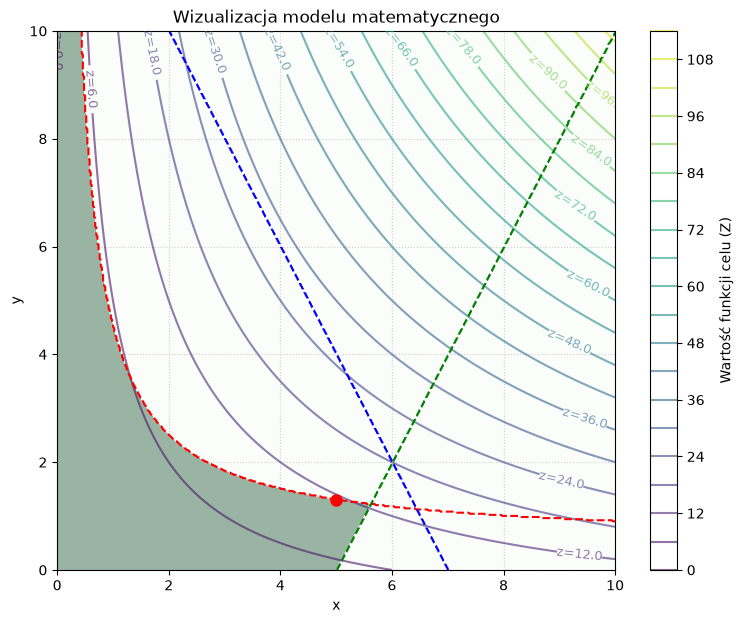

In [114]:
draw_model(
    constraints=constraints,
    target_fn=target,
    optimal_parameters=(x_val, y_val),
)